 # Scenario: Customer Segmentation for a Retail Store
Context:
A retail store wants to understand its customers better. They have data on how much each customer spends per visit and how frequently they visit the store. The goal is to group customers into clusters (e.g., “loyal high spenders,” “occasional visitors,” etc.) using DBSCAN, which is great for finding clusters of varying shapes and identifying outliers.

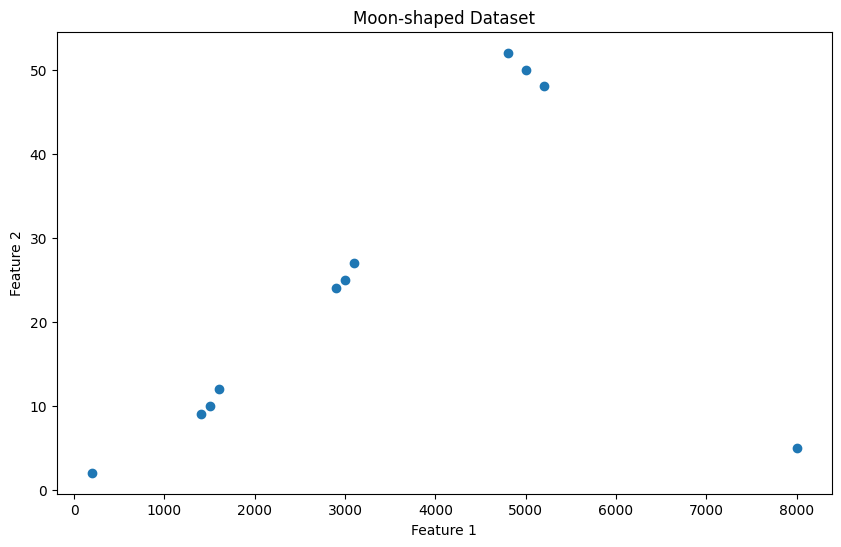

In [1]:
import numpy as np # Imports the NumPy library, which is used for numerical operations and handling arrays.
import matplotlib.pyplot as plt # Imports Matplotlib's pyplot module, which is used for creating visualizations like plots and graphs.
from sklearn.datasets import make_moons # Imports the make_moons function from Scikit-learn, which generates a synthetic dataset with a moon shape, often used for clustering and classification tasks.
from sklearn.cluster import DBSCAN # Imports the DBSCAN clustering algorithm from Scikit-learn, which is used for density-based clustering.
from sklearn.neighbors import NearestNeighbors # Imports the NearestNeighbors class from Scikit-learn, which is used to find the nearest neighbors of a point in a dataset.


data = np.array([
    [5000, 50], [5200, 48], [4800, 52],   # Loyal high spenders
    [1500, 10], [1600, 12], [1400, 9],    # Occasional visitors
    [3000, 25], [3100, 27], [2900, 24],   # Moderate spenders
    [8000, 5],                            # Outlier: rare but huge spender
    [200, 2],                             # Outlier: very low engagement
])

plt.figure(figsize=(10, 6)) # creates a new figure with a size of 10 inches by 6 inches.
plt.scatter(data[:, 0], data[:, 1]) # plots a scatter plot using the first and second columns of the dataset X.
plt.title('Moon-shaped Dataset') # Adds the title 'Moon-shaped Dataset' to the plot.
plt.xlabel('Feature 1') # Labels the x-axis as 'Feature 1'.
plt.ylabel('Feature 2') # Labels the y-axis as 'Feature 2'.
plt.show()

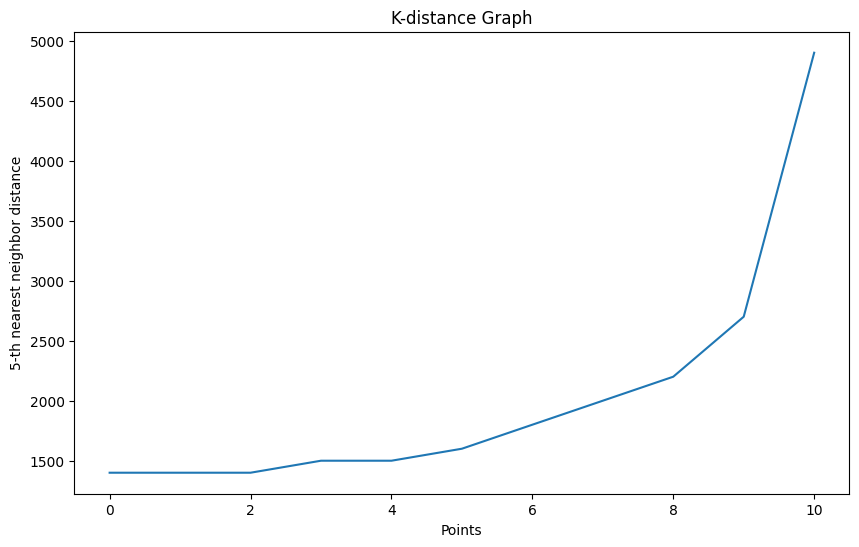

In [3]:
def plot_k_distance_graph(X, k):
    neigh = NearestNeighbors(n_neighbors=k)
    neigh.fit(data)
    distances, _ = neigh.kneighbors(data)
    # NearestNeighbors(n_neighbors=k): Initializes the NearestNeighbors model to find the k-nearest neighbors.
    # neigh.fit(X): Fits the model using the dataset X.
    # distances, _ = neigh.kneighbors(X): Computes the distances to the k-nearest neighbors for each point in X.
    distances = np.sort(distances[:, k-1])
    # This sorts the distances to the k-th nearest neighbor for each point in ascending order
    plt.figure(figsize=(10, 6))
    plt.plot(distances)
    plt.xlabel('Points')
    plt.ylabel(f'{k}-th nearest neighbor distance')
    plt.title('K-distance Graph')
    plt.show()
    # plt.figure(figsize=(10, 6)): Creates a new figure with a specified size.
    # plt.plot(distances): Plots the sorted distances.
    # plt.xlabel('Points'): Labels the x-axis as 'Points'.
    # plt.ylabel(f'{k}-th nearest neighbor distance'): Labels the y-axis with the k-th nearest neighbor distance.
    # plt.title('K-distance Graph'): Sets the title of the plot.
    # plt.show(): Displays the plot.
    # Plot k-distance graph
plot_k_distance_graph(data, k=5)